# CS1090a Final Project Milestone 5

### Project  Title: Comparing Linear and Polynomial Models’ Ability to Predict Blood Lactate Levels with Metabolic and Biomechanical Indicators  

**Group Members:**

- David Soucie(sirob7007@gmail.com)

- Eva Harris (evaharris@college.harvard.edu)

- Ethan Aidam (eaidam@college.harvard.edu)

- Sam Burgess (sburgess@college.harvard.edu)

- Shay Li (sineadli@college.harvard.edu)


## Table of Contents

* [1 - Problem Statement](#1---problem-statement)
* [2 - Data Description](#2---data-description)

* [3 - Processing / EDA](#3---processing--eda)
    * [3.1 - Exploration of Qualities](#31---exploration-of-qualities)
        * [3.1.1 - By Individual Day](#311---by-individual-day)
        * [3.1.2 - Combined Dataset](#312---combined-dataset)
        * [3.1.3 - Conclusions of Qualities Analysis](#313---conclusions-of-qualities-analysis)
    * [3.2 - All Feature Trace Plots](#32---all-feature-trace-plots)
        * [3.2.1 - Mechanical Output](#321---mechanical-output)
        * [3.2.2 - Metabolism](#322---metabolism)
        * [3.2.3 - Cardio](#323---cardio)
    * [3.3 - All Feature Histograms](#33---all-feature-histograms)
    * [3.4 - Correlation Analysis](#34---correlation-analysis)
        * [3.4.1 - Combined Dataset](#341---combined-dataset)
        * [3.4.2 - By Individual Day](#342---by-individual-day)
    * [3.5 - Findings Summary](#35---findings-summary)

* [4 - Baseline Model](#4---baseline-model)
    * [4.1 - Simple Linear Regression](#41---simple-linear-regression)
    * [4.2 - Multiple Linear Regression](#42---multiple-linear-regression)
    * [4.3 - Model with Interaction Terms](#43---model-with-interaction-terms)
    * [4.4 - Polynomial Term (squared terms)](#44---polynomial-term-squared-terms)
    * [4.5 - Model Selection Comparison](#45---model-selection-comparison)
        * [4.5.1 - Assumption Checking for Linear Models](#451---assumption-checking-for-linear-models)

* [5 - Prediction Models](#5---prediction-models)
    * [5.1 - Standard (OLS) Multiple Linear Regression](#51---standard-ols-multiple-linear-regression)
    * [5.2 - LASSO](#52---lasso)
    * [5.3 - RIDGE](#53---ridge)
    * [5.4 - Polynomial](#54---polynomial)

* [6 - Tree Models](#6---tree-models)
    * [6.1 - Decision Tree](#61---decision-tree)
    * [6.2 - Random Forest](#62---random-forest)
    * [6.3 - Gradient Boosting](#63---gradient-boosting)
    * [6.4 - Mixture of Experts](#64---mixture-of-experts)
    * [6.5 - Model Comparisons](#65---model-comparisons)

* [7 - Extension: A Feature Exploration of Oxygen Saturation (Bayesian Hierarchical Model)](#7---extension-a-feature-exploration-of-oxygen-saturation-bayesian-hierarchical-model)

* [8 - Conclusion](#8---conclusion)

## 1 - Problem Statement

**Motivation:** Understanding the factors influencing blood lactate threshold is vital for assessing athletic performance and designing personalized training. Our project explores the usage of models to capture trends in blood lactate across exercise intensities. Since blood lactate test generally require blood samples, it generally is an added cost for elite athletic teams. If a model were to accurately predict lactate from data, testing could be done on a less-frequent basis. Thus, reducing costs and saving time for elite athletes. 

 Our **main goals** for our model evaluation is:

    - How well do models predict the Blood Lactate level, given several other easier to measure features?

The **overall goal** in these evaluations is to determine whether  methods for predicting blood lactate should presume a linear or non-linear relationship between the predictors and target. At the moment, we hypothesize that traditional linear models may oversimplify the nonlinear relationships between biomechanical variables (e.g., cadence) and metabolic measures ($VO_2$ max, heart rate). We are evaluating our conclusion such that if the best performing model is linear, a linear relationship can be determined. Likewise if the best performing model is non-linear (e.g. polynomial regression, tree-based models), a non-linear relationship can be determined. Best performance will be measured using $R^2$ values.

**Import Libraries**

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from scipy import stats
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# pandas tricks for better display
pd.options.display.max_columns = 50  
pd.options.display.max_rows = 500     
pd.options.display.max_colwidth = 100
pd.options.display.precision = 3

## 2 - Data Description

We will use a dataset from Kaggle titled ["Cycling[La]: Blood Lactate Concentration During Cycling High Intensity Interval Training"](https://www.kaggle.com/datasets/andreazignoli/cycling-la/). 

This data was collected from a single high performance athlete being tested forlactate using an indoor cycler across 3 days of testing, using various wearable devices and monitors. As you will see through our EDA, the intervals at which the athlete was active changed each day. We did our best to handle this accordingly.

The data was entirely complete, with no null values. Most values are floats, though a few values are integers; all are numeric. Each row of the dataset is a specific second of the training session, and each feature is a biometric observation specific to that second.


Our processed dataset includes 8 features from the below original dataset, all of which with 8818 entries:

| Feature            | Description                                                    | Units / Notes      |
| ------------------ | -------------------------------------------------------------- | ------------------ |
| `time`             | Second of the test when the measurement was taken              | seconds            |
| `power`            | Cycling power output                                           | watts              |
| `VO2`**(dropped)** | Oxygen consumption                                             | O₂/min             |
| `cadence`          | Cycling cadence (revolutions per minute)                       | RPM                |
| `lactate`          | Blood lactate concentration                                    | mmol/L             |
| `rf`               | Respiratory frequency                                          | breaths per minute |
| `heart_rate`       | Heart rate                                                     | beats per minute   |
| `saturation`       | Blood oxygen saturation                                        | percentage (%)     |
| `day`              | Day on which the data was collected (pre-processing indicator) | 1, 2, or 3         |


## 3 - Processing / EDA

**Data Loading**

In order to evaluate whether the data behaves differently across days of training, we consider 4 datasets in total. First, we loaded data from each of the three days from the Kaggle, and named them `kaggle_day[n]_df`, for $n \in [1, 3]$ accordingly. Each dataframe correspondes to the associated day of the training session. Then, we concatenated all three datasets into one overall dataset titled `day_all_lactate_challenge.csv`, and added a new column of "Day" so we could recognize the day that any specific row's observation was taken. For simplicity, our overall dataset is denoted as `df` through this notebook.

In [6]:
kaggle_day1_df = pd.read_csv("data/day1_lactate_challenge.csv")
kaggle_day2_df = pd.read_csv("data/day2_lactate_challenge.csv")
kaggle_day3_df = pd.read_csv("data/day3_lactate_challenge.csv")

kaggle_day1_df["day"] = 1
kaggle_day2_df["day"] = 2
kaggle_day3_df["day"] = 3

df = pd.concat([kaggle_day1_df, kaggle_day2_df, kaggle_day3_df], ignore_index=True)
df.to_csv('data/day_all_lactate_challenge.csv', index=False)
df.head()

,time,power,VO2,cadence,lactate,rf,heart_rate,saturation,day
0,1,0,313.460,0,0.749,18.445,52.5,99.0,1
1,2,0,214.150,0,0.748,17.962,53.0,99.0,1
2,3,0,114.840,0,0.747,17.480,53.5,99.0,1
3,4,0,15.532,0,0.746,16.997,54.0,99.0,1
4,5,0,247.580,0,0.745,16.748,54.0,99.0,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8818 entries, 0 to 8817
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time        8818 non-null   int64  
 1   power       8818 non-null   int64  
 2   VO2         8818 non-null   float64
 3   cadence     8818 non-null   int64  
 4   lactate     8818 non-null   float64
 5   rf          8818 non-null   float64
 6   heart_rate  8818 non-null   float64
 7   saturation  8818 non-null   float64
 8   day         8818 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 620.1 KB



We noticed that in calling `df.head`, there are 0's in `power` and `cadence`. This is strange. Additionally the `Non-Null Count` from `.info()` tells us that we have no null values. We will further parse the qualities of each individual day to see if there are 0's across  `power` and `cadence` among all three days or if it simply was not recorded on that day. 

### 3.1 - Exploration of Qualities

**Dataset Qualities**

The qualities used to analyze the dataset are:

| Statistic          | Description                                                      |
| ------------------ | ---------------------------------------------------------------- |
| Mean               | Mean (average) value of all observations in the column           |
| Standard Deviation | Standard deviation of all observations in the column             |
| Maximum            | Maximum value observed in the column                             |
| Minimum            | Minimum value observed in the column                             |
| Outliers           | Number of observations with an absolute z-score greater than 2.5 |

^*We created a helper function defined as `calc_outliers`, which is designed to calculate the numner of outliers present in each feature. Our `Outliers` count was determined based upon z-score.*



In [8]:
# Function takes in a dataframe, then outputs a tall dataframe with a single column containing the outlier count for each column of the inputted dataframe, and each row representing a column of the inputted dataframe
def calc_outliers(in_df):
    output = pd.DataFrame()
    for column in in_df.columns:
        z_score = np.abs(stats.zscore(in_df[column]))
        output[column] = [in_df[z_score > 2.5][column].count()]
    return pd.melt(output, value_vars = in_df.columns, var_name = "index", value_name = "Outliers").set_index("index")

#### 3.1.1 - By Individual Day

Next, we decided to parse the individual days to get a picture regarding the data in each day. We are selecting into each day from our concatanted dataset, since this is the dataset we are focused on processing. By analyzing each day individually, we can better understand the variation between the days and how this may affect our analysis later in this notebook.


**Day 1**

In [9]:
# Day 1 Qualities
df_day1 = df.loc[df["day"] == 1]

pd.DataFrame({"Null count": df_day1.isnull().sum(),
              "Mean": df_day1.mean(),
              "Standard Deviation": df_day1.std(),
              "Maximum": df_day1.max(),
              "Minimum": df_day1.min(),
              "Outliers": [val[0] for val in calc_outliers(df_day1).values]})


/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_47848/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1619.500,934.874,3238.000,1.000,0
power,0,129.608,97.694,350.000,0.000,0
VO2,0,2140.876,1034.657,4788.300,15.532,2
cadence,0,70.748,41.793,112.000,0.000,0
lactate,0,4.593,2.865,9.790,0.630,0
rf,0,24.898,6.376,75.483,6.920,85
heart_rate,0,121.027,31.156,177.000,49.000,0
saturation,0,96.981,1.352,99.000,94.000,0
day,0,1.000,0.000,1.000,1.000,0


We know from calling `df.head()` earlier that some values in Day 1 are 0's. However, in this chart, we can see that the mean of `cadence` and `power` are non-zero. This means that we have 0's intermixed with non-zero data. I will now explore these 0's further to decide whether they occur due to a collection error or are an aspect of the data. 



Assuming they are not a collection error, I have to think that the athlete was resting rather than actively biking. Given this, it would make sense to see their heart rate (and maybe their lactate) drop at the same time. To explore this, I will be using trace plots. 

The first trace plot I will create is a plot of lactate versus time. I will use a binary indicator to show me when both `power` and `cadence` are zero (Indicator=0) versus non-zero (Indicator=1). I will then plot this indicator againt time, just like my previous plot. In my final trace plot, I will plot heart `heart_rate` versus time. 

Based on my personal experience with heart rate and lactate, heart rate will drop sharply, and lactate will follow at a slower rate if the athlete is at rest. 

In [10]:
df1 = df_day1.copy()

# Indicator: both power and cadence are zero
df1["zero_both"] = (df1["power"] == 0) & (df1["cadence"] == 0.0)
df1["zero_label"] = df1["zero_both"].map({True: "Power & Cadence = 0",
                                          False: "Power & Cadence > 0"})

# Bin time into quartiles for boxplots "with respect to time"
df1["time_bin"] = pd.qcut(df1["time"], q=4,
                          labels=["Early (Q1)", "Q2", "Q3", "Late (Q4)"])

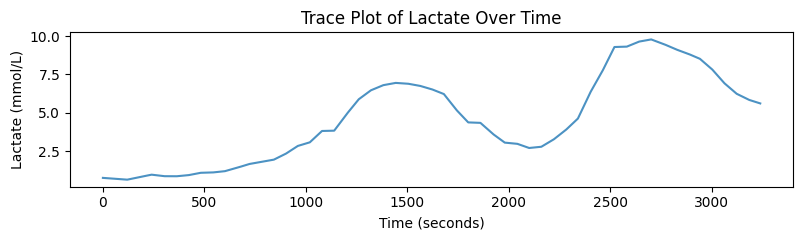

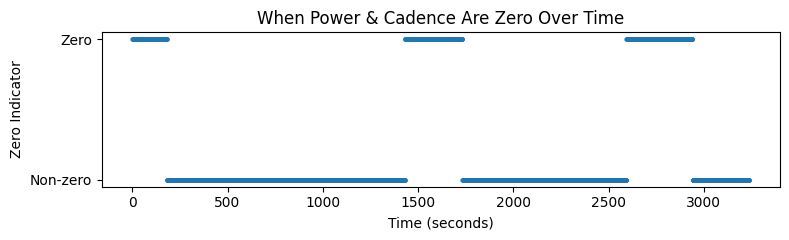

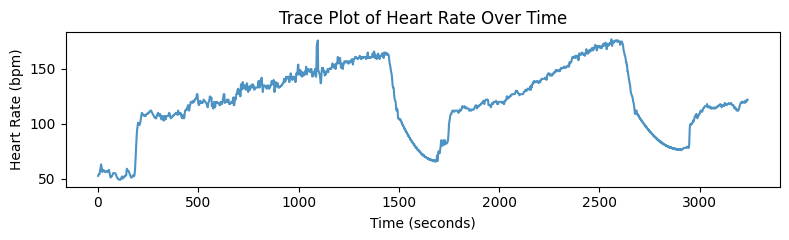

In [11]:
# trace plots

# Lactate vs Time
# Trace plot of lactate over continuous time
plt.figure(figsize=(8, 2.5))
plt.plot(df1["time"], df1["lactate"], alpha=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Lactate (mmol/L)")
plt.title("Trace Plot of Lactate Over Time")
plt.tight_layout()
plt.show()


# Zeros vs Non-Zeros with respect to Time
# Trace plot: binary indicator of zero vs non-zero over time
plt.figure(figsize=(8, 2.5))
plt.scatter(df1["time"],
            df1["zero_both"].astype(int),
            s=5, alpha=0.8)
plt.yticks([0, 1], ["Non-zero", "Zero"])
plt.xlabel("Time (seconds)")
plt.ylabel("Zero Indicator")
plt.title("When Power & Cadence Are Zero Over Time")
plt.tight_layout()
plt.show()


# Heart Rate vs Time
# Trace plot of heart rate over time
plt.figure(figsize=(8, 2.5))
plt.plot(df1["time"], df1["heart_rate"], alpha=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Trace Plot of Heart Rate Over Time")
plt.tight_layout()
plt.show()


Our indicator variable lines up perfectly with drops in `heart_rate` and `lactate`! This confirms that when `power = 0` and `cadence = 0`, the athlete is at rest. 

Now I want to check whether `power` and `cadence` will always = 0 at the same time.  


In [12]:
# Rows where power == 0 but cadence != 0
power_zero_cadence_nonzero = df[(df["power"] == 0) & (df["cadence"] != 0.0)]

# Rows where cadence == 0 but power != 0
cadence_zero_power_nonzero = df[(df["cadence"] == 0.0) & (df["power"] != 0)]

len(power_zero_cadence_nonzero), len(cadence_zero_power_nonzero)


(0, 5)

There are no instances in which `power` = 0 but `cadence` is not equal to 0. However, we have **five** instances (in the concatenated dataset, so across all three days) in which `cadence` drops off before `power` does. I  decided to print out the five values in `cadence_zero_power_nonzero` below.

In [13]:
print(cadence_zero_power_nonzero[["time", "power", "cadence", "day"]])

      time  power  cadence  day
181    182    100        0    1
1732  1733     93        0    1
2940  2941     98        0    1
2941  2942     99        0    1
3418   181     98        0    2


I'm not an avid cyclist, however, it would make sense that `cadence` drops before `power` registers zero or that the flywheel still produces power momentarily after the biker has stopped pedaling. The trace plot that plotted `heart_rate` against `time` from earlier appeared to be most aligned with the motions of the athlete, so let's add the points from  `cadence_zero_power_nonzero` see if this confirms our logic.

It appears that **four** of the points are in day 1, so I will use the same `df1` I used for the previous trace plots. These **four** points should be able to give us intuition for the pattern of where this occurs. (note the graph below looks like **three** points because the points at `time` = 2941 and `time` = 2942 seconds have overlapped)

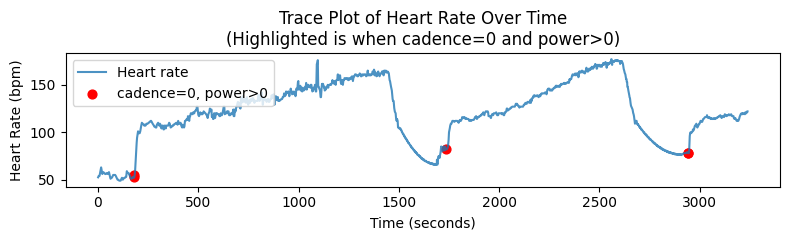

In [14]:
# Heart Rate vs Time (with marks on cadence_zero_power_nonzero)
plt.figure(figsize=(8, 2.5))
plt.plot(df1["time"], df1["heart_rate"], alpha=0.8, label="Heart rate")
plt.scatter(
    cadence_zero_power_nonzero["time"],
    cadence_zero_power_nonzero["heart_rate"],
    color="red",
    s=40,
    label="cadence=0, power>0"
)
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Trace Plot of Heart Rate Over Time\n(Highlighted is when cadence=0 and power>0)")
plt.legend()
plt.tight_layout()
plt.show()

This is really interesting. Contrary to what we thought, it appears that `cadence_zero_power_nonzero` only actually occcurs when the biker is starting to pedal again.

As a part of our preprocessing, I will create a new column such that it only contains nonzero values of power and cadence. This will help us later compare active riding versus the full session. I will also print our `Qualities` chart again to reflect the changes. 

In [15]:
df["cadence_nonzero"] = df["cadence"].where(df["cadence"] > 0)
df["power_nonzero"]= df["power"].where(df["power"] > 0)

# Day 1 Qualities (V2)
df_day1 = df.loc[df["day"] == 1]

pd.DataFrame({"Null count": df_day1.isnull().sum(),
              "Mean": df_day1.mean(),
              "Standard Deviation": df_day1.std(),
              "Maximum": df_day1.max(),
              "Minimum": df_day1.min(),
              "Outliers": [val[0] for val in calc_outliers(df_day1).values]})

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_47848/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1619.500,934.874,3238.000,1.000,0
power,0,129.608,97.694,350.000,0.000,0
VO2,0,2140.876,1034.657,4788.300,15.532,2
cadence,0,70.748,41.793,112.000,0.000,0
lactate,0,4.593,2.865,9.790,0.630,0
rf,0,24.898,6.376,75.483,6.920,85
heart_rate,0,121.027,31.156,177.000,49.000,0
saturation,0,96.981,1.352,99.000,94.000,0
day,0,1.000,0.000,1.000,1.000,0
cadence_nonzero,833,95.253,4.099,112.000,52.000,0


**Day 2**

In [16]:
# Day 2 Qualities

#drawing from our combined dataset for consistency
df_day2 = df.loc[df["day"] == 2]

pd.DataFrame({"Null count" : df_day2.isnull().sum(),
              "Mean" : df_day2.mean(), 
              "Standard Deviation" : df_day2.std(), 
              "Maximum" : df_day2.max(), 
              "Minimum" : df_day2.min(),
             "Outliers": [val[0] for val in calc_outliers(df_day2).values]})

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_47848/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1590.500,918.131,3180.000,1.000,0
power,0,145.148,111.674,596.000,0.000,57
VO2,0,2493.999,939.473,4869.200,15.086,25
cadence,0,80.304,35.378,145.000,0.000,0
lactate,0,4.399,2.180,7.630,0.580,0
rf,0,27.894,6.684,56.075,4.481,70
heart_rate,0,123.464,26.770,166.000,51.000,125
saturation,0,95.436,1.478,99.000,91.000,1
day,0,2.000,0.000,2.000,2.000,0
cadence_nonzero,506,95.500,6.063,145.000,29.000,0


Following from our analysis on day1, it makes sence that day2 has a minimum power and cadence of 0 because when we explored `cadence_zero_power_nonzero`, we found an occurance in day 2 as well. Everything else looks normal. I will explore how each feature behaves against time in the section about the combined dataset.

**Day 3**

In [17]:
# Day 3 Qualities

#drawing from our combined dataset for consistency
df_day3 = df.loc[df["day"] == 3]


pd.DataFrame({"Null count" : df_day3.isnull().sum(),
              "Mean" : df_day3.mean(), 
              "Standard Deviation" : df_day3.std(), 
              "Maximum" : df_day3.max(), 
              "Minimum" : df_day3.min(),
              "Outliers": [val[0] for val in calc_outliers(df_day3).values]})

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_47848/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1200.500,692.965,2400.000,1.000,0
power,0,112.067,131.468,778.000,0.000,123
VO2,0,2273.196,1038.358,4561.700,2.415,0
cadence,0,76.800,41.585,170.000,0.000,0
lactate,0,7.564,3.708,11.160,0.610,0
rf,0,28.701,8.953,63.158,9.624,40
heart_rate,0,115.822,30.254,161.000,48.000,0
saturation,0,97.044,1.593,99.000,93.000,13
day,0,3.000,0.000,3.000,3.000,0
cadence_nonzero,496,96.807,15.565,170.000,66.000,0


Following from our analysis on day1, it makes sence that day2 has a minimum power and cedence of 0 because when we explored `cadence_zero_power_nonzero`, we found an occurance in day 2 as well. Everything else looks normal. I will explore how each feature behaves against time in the section about the combined dataset.


#### 3.1.2 - Combined Dataset

**Qualities**

In [18]:
pd.DataFrame({"Null count" : df.isnull().sum(), 
              "Mean" : df.mean(), 
              "Standard Deviation" : df.std(), 
              "Maximum" : df.max(), 
              "Minimum" : df.min(),
              "Outliers": [val[0] for val in calc_outliers(df).values]})

,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1495.002,887.722,3238.000,1.000,0
power,0,130.438,113.461,778.000,0.000,184
VO2,0,2304.235,1013.736,4869.200,2.415,1
cadence,0,75.841,39.749,170.000,0.000,0
lactate,0,5.332,3.215,11.160,0.580,0
rf,0,27.014,7.453,75.483,4.481,181
heart_rate,0,120.489,29.547,177.000,48.000,0
saturation,0,96.441,1.649,99.000,91.000,17
day,0,1.905,0.794,3.000,1.000,0
cadence_nonzero,1835,95.771,9.290,170.000,29.000,0


#### 3.1.3 - Conclusions of Qualities Analysis

Some variation can be seen in the mean and standard deviation of each field on a per-day basis. However, unless these differences are also reflected in the correlations for each feature, it should not affect the results significantly.

What could more significantly affect results is the high discrepency between mean, variance, and standard deviation between the different features, as well as a number of outliers within the data. Since our testing will go on to include polynomial regression at higher orders, scaling will be needed to prevent numerical instability. 


### 3.2 - All Feature Trace Plots

Overall, we want to look at how the features change over time, split by days. Thus, we wrote a function plot_trace_feature to display trace plots for each feature over time, split by days.

In [19]:
def plot_trace_feature(feature):
    fig, axes = plt.subplots(1, 3, figsize=(24, 2.5))

    # Day 1
    axes[0].plot(df_day1["time"], df_day1[feature], alpha=0.8)
    axes[0].set_xlabel("Time (seconds)")
    axes[0].set_ylabel(feature)
    axes[0].set_title(f"Day 1: Trace Plot of {feature} Over Time")

    # Day 2
    axes[1].plot(df_day2["time"], df_day2[feature], alpha=0.8)
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel(feature)
    axes[1].set_title(f"Day 2: Trace Plot of {feature} Over Time")

    # Day 3
    axes[2].plot(df_day3["time"], df_day3[feature], alpha=0.8)
    axes[2].set_xlabel("Time (seconds)")
    axes[2].set_ylabel(feature)
    axes[2].set_title(f"Day 3: Trace Plot of {feature} Over Time")

    plt.tight_layout()
    plt.show()

#### 3.2.1 - Mechanical Output

These features pertain to how the athlete performed physically.

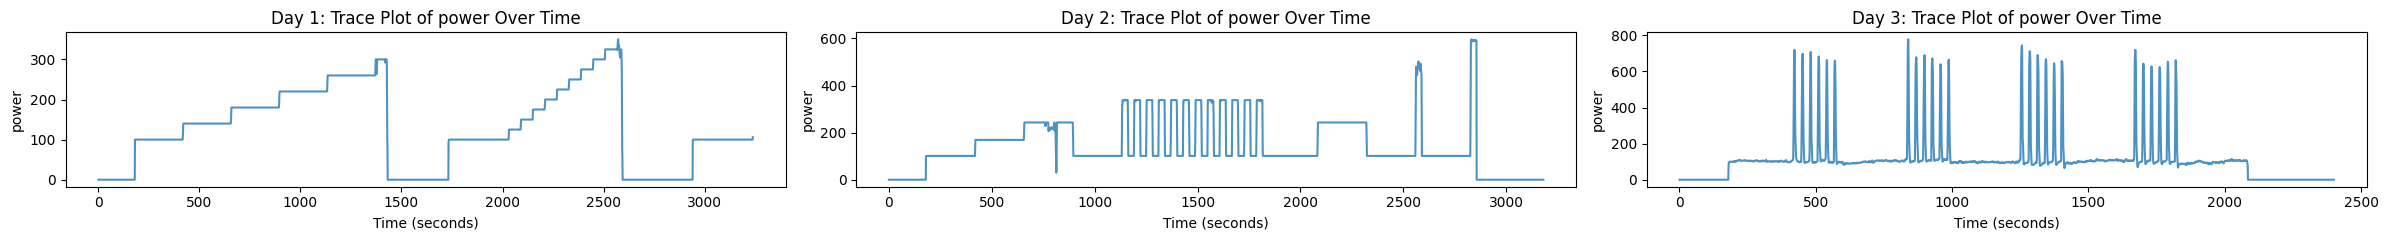

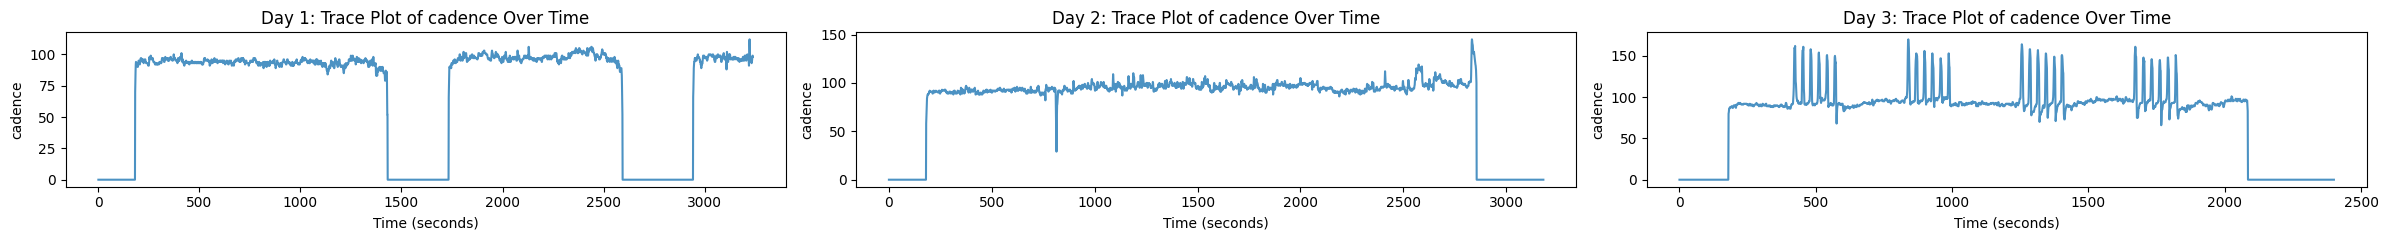

In [20]:
for feat in ["power", "cadence"]:
    plot_trace_feature(feat)

The trace plots for power and cadence look noticeably different on Day 3 compared to Days 1 and 2. Day 3 has lots of short, sharp bursts where the athlete suddenly pushes very hard.

#### 3.2.2 - Metabolism

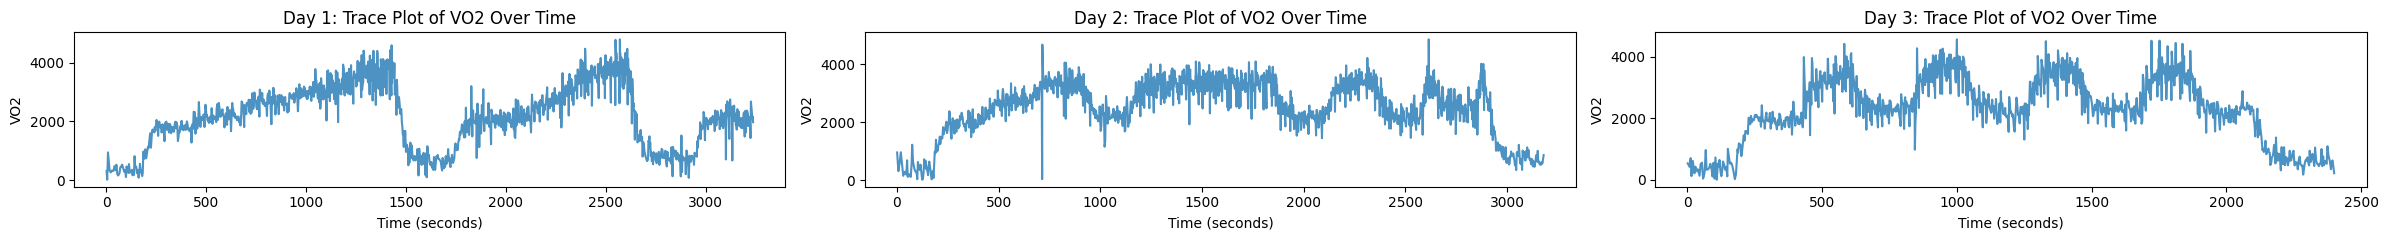

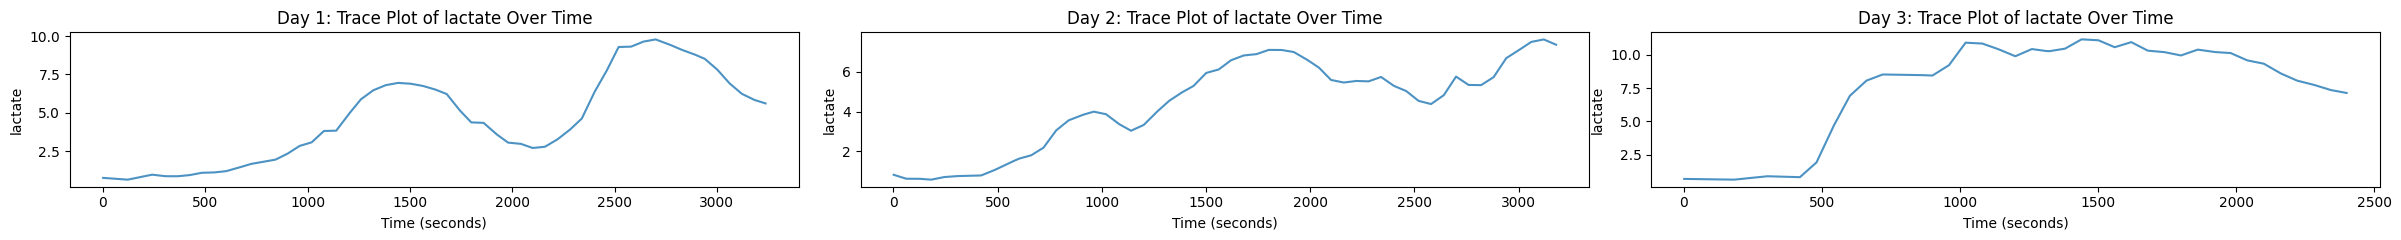

In [21]:
for feat in ["VO2", "lactate"]:
    plot_trace_feature(feat)

#### 3.2.3 - Cardio

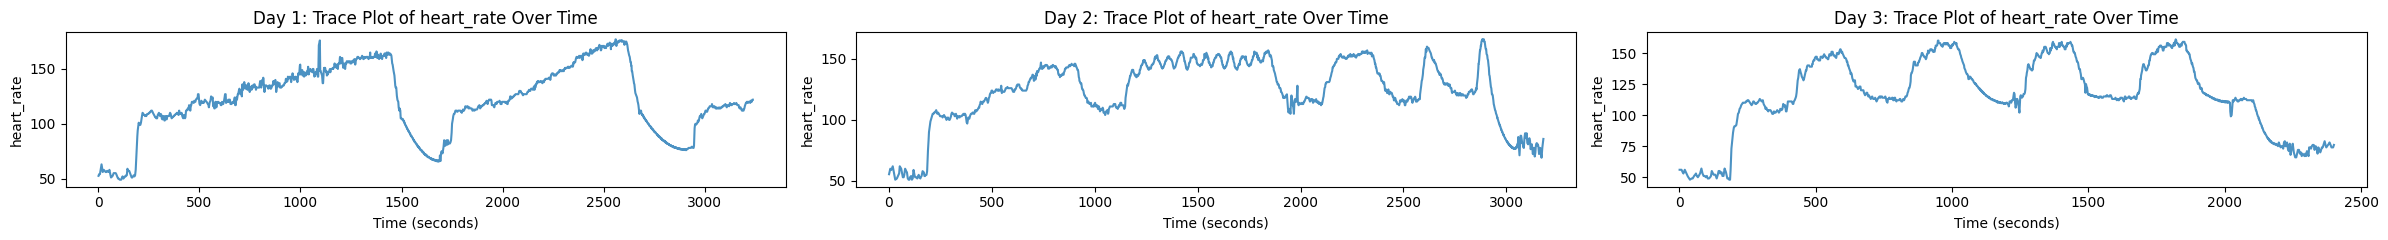

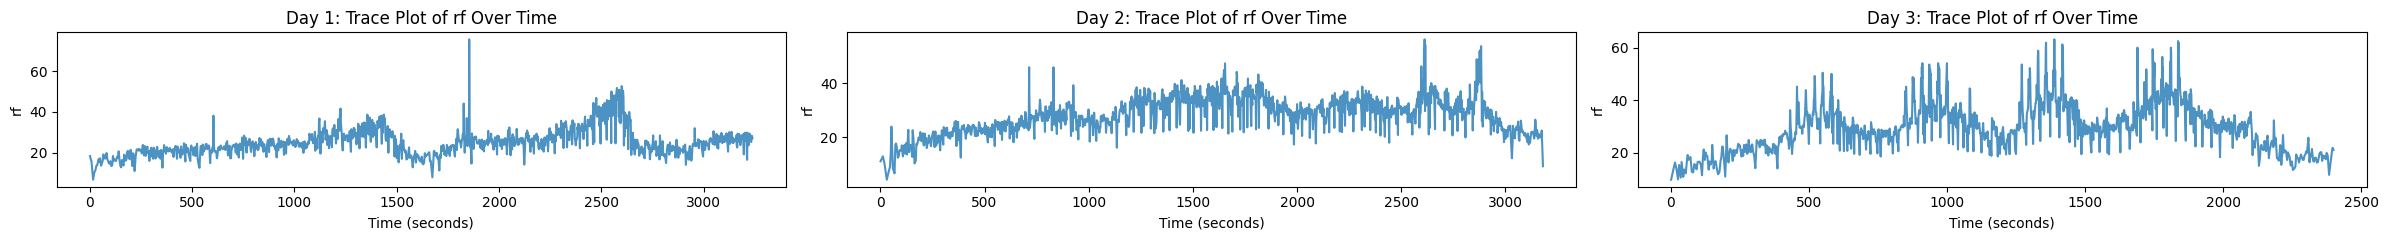

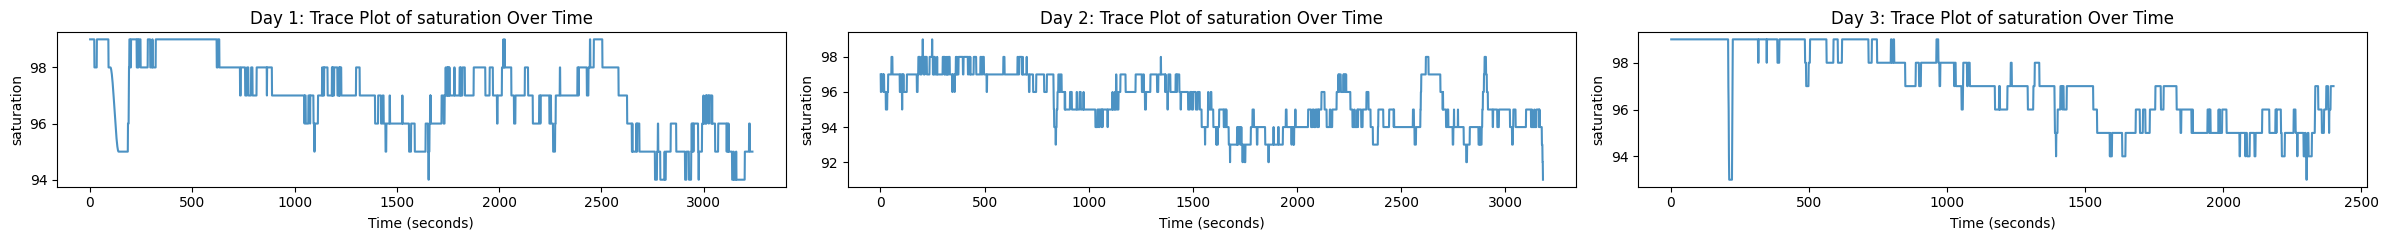

In [22]:
for feat in ["heart_rate", "rf", "saturation"]:
    plot_trace_feature(feat)

*Note: Saturation does not have any float values, which is why it appears to jump around more.*

The athlete held a similar power and cadence level for the majority of the test, but with occasional bursts of higher levels of power and speed. This matches the typical process for physiological testing, with a default steady pace followed by bursts of max effort at specific intervals. In total, across all variables, the trace plots clearly indicate that the athlete completed different interval structures on each testing day. 

- On Day 1, heart rate, power, cadence, and VO2 display long, steady intervals that slowly increase through the graph. These periods are followed by extended recoveries, consistent with a traditional incremental step test. 

- Day 2 shows a notably different pattern. There are multiple sharp spikes in power and heart rate that reflect repeated high-intensity parts. Additionally, cadence and VO2 fluctuate more frequently, indicating interval repeats rather than sustained blocks. 

- Day 3 diverges yet again. There are very rapid oscillations in power and cadence that correspond to short, high-frequency sprint intervals. This produces distinct heart rate and lactate patterns especially when compared to the prior days. 

Together, these plots confirm that the physiological data were generated under three unique workout protocols, meaning each “day” represents a different training or testing stimulus. This tells us that we should implement models such a random forest or a mixture of experts to account for this variation, rather than assuming a single unified relationship across all days of testing.

### 3.3 - All Feature Histograms

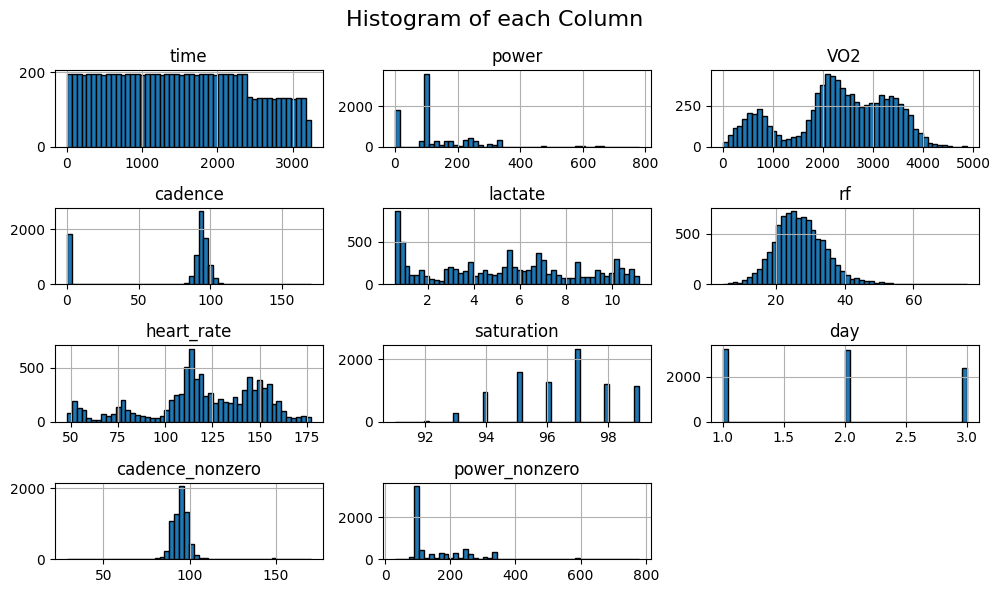

In [23]:
df.hist(figsize=(10, 6), bins = 50, edgecolor = "black")

plt.suptitle("Histogram of each Column", fontsize = 16)
plt.tight_layout()
plt.show()

No noteworthy concerns from the histogram, though some features do give insight on the nature of the performance. Notably, time distribution shows that each session did not have the exact same total training time, since certain time values are less represented than others. Day 3 appears to have less observation than Day 2 and Day 1. 

### 3.5 - Correlation Analysis


**Hierarchical Clustered Correlation Heatmap**

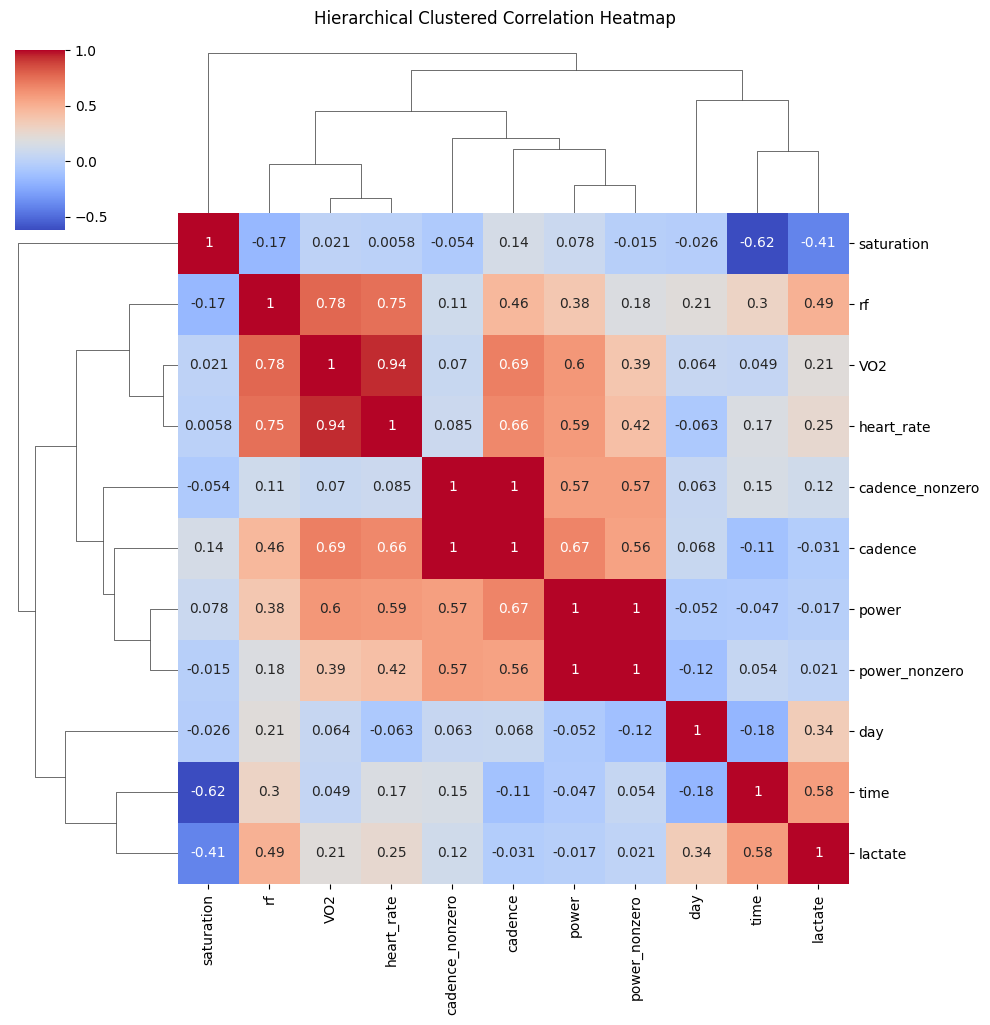

In [24]:
corr = df.corr()

sns.clustermap(corr, cmap="coolwarm", annot=True)

plt.suptitle("Hierarchical Clustered Correlation Heatmap", y=1.02)
plt.show()

Our hierarchical clustered correlation heatmap highlights several clear structure patterns in the data. 

- Heart rate, respiratory frequency (`rf`), cadence, and power cluster together. his reflects a shared underlying exercise intensity signal. As workload increases, these physiological measures tend to rise in tandem (e.g., heart rate–rf ≈ 0.75, cadence–power ≈ 0.67). 

- Time and lactate form a separate cluster with a moderately strong positive correlation (≈ 0.58). This indicating that lactate accumulation increases over the course of the workout, consistent with fatigue and metabolic by-product build-up during sustained effort. 

- Saturation stands apart from most variables and is negatively correlated with time (≈ −0.62) and lactate (≈ −0.41). This suggests that oxygen saturation tends to decline as exercise progresses and lactate rises. 

The structure reinforces the idea that while multiple predictors reflect a common intensity dimension, lactate and saturation capture downstream physiological consequences over time, motivating models that allow time-dependent structure and partial pooling (e.g., hierarchical effects by day in `Section 6`) rather than treating all predictors as independent signals.


#### 3.5.1 - Combined Dataset

In [25]:
# Takes in an input of a correlation matrix, and returns a dataset that 
# neatly displays every single correlation, sorted from highest correlated 
# interaction to lowest.
#      - no self-correlations (corr(x, x))
#      - no duplicate symmetric pairs (corr(x, y) and corr(y, x))
def display_corr_total(corr):
    corr_flat = (
        corr.unstack()
             .reset_index()
             .rename(columns={'level_0': 'Variable 1',
                              'level_1': 'Variable 2',
                              0: 'Correlation'})
    )
    corr_flat = corr_flat[corr_flat['Variable 1'] != corr_flat['Variable 2']]
    corr_flat = corr_flat.drop_duplicates(subset=['Correlation'])
    
    corr_flat = corr_flat.sort_values(by='Correlation', ascending=False)
    return corr_flat

display_corr_total(corr)



,Variable 1,Variable 2,Correlation
21,power,power_nonzero,1.000
28,VO2,heart_rate,0.938
27,VO2,rf,0.779
61,rf,heart_rate,0.745
25,VO2,cadence,0.694
14,power,cadence,0.672
39,cadence,heart_rate,0.664
13,power,VO2,0.603
17,power,heart_rate,0.594
4,time,lactate,0.581


By standard machine learning practice, I will now use a threshold correlation of $0.8$ to capture potential multicollinearity. 

In [26]:
def display_corr_pairs(corr, threshold=0.8):
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # keep upper triangle only
            .stack()
            .reset_index()
    )
    corr_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    corr_pairs = corr_pairs.loc[corr_pairs["Correlation"].abs() > threshold]
    corr_pairs = corr_pairs.sort_values("Correlation", ascending=False)
    
    return corr_pairs

display_corr_pairs(corr)

,Variable 1,Variable 2,Correlation
18,power,power_nonzero,1.000
32,cadence,cadence_nonzero,1.000
22,VO2,heart_rate,0.938


The above printed correlation plots tell us that `heart_rate` and `VO2` are most highly correlated. The have a calculated correlation of 0.938. Because `heart_rate` is generally a far more accessible metric to calcuate than `VO2`, we will be dropping `VO2`.

In [27]:
df = df.drop(columns=["VO2"])

#### 3.5.2 - By Individual Day

We will now consider how the correlations change through the days of training. Below, I have maintained the threshold correlation of $0.8$ to capture potential multicollinearity and have printed the relevant correlations so we can analyze them.

**Day 1**

In [28]:
#to reflect update of dropping VO2
df_day1 = df.loc[df["day"] == 1]

display_corr_pairs(df_day1.corr())

,Variable 1,Variable 2,Correlation
14,power,power_nonzero,1.000
19,cadence,cadence_nonzero,1.000
32,heart_rate,power_nonzero,0.937
11,power,heart_rate,0.825
2,time,lactate,0.807


Interpretation:

- `lactate` x `time`: I don't think we do anything about this because lactate is our predictor and time tells us the flow of our data through the lactate test

- `power` x `heart_rate`: This is interesting, but all it means is that when the power output goes up, the athlete's heart rate tends to rise, so it is expected. However, this correlation did not come up when analyzing our overall df so I want to see how it changes throught the days. The nice thing about power and cadence is that they are both better suited for understanding whether the athlete is actively in the piece or at rest, but if heart_rate can tell us the same info then it makes sense to drop them as we go to fit more advanced models.

- `power_nonzero` x `heart_rate`: See above. Depending on circumstance and what we are looking for explore, use power_nonzero or just power. But never both.

- `cadence` x `cadence_nonzero`, `power` x `power_nonzero`: Depending on circumstance and what we are looking for explore, use one or the other. But never both.

^**Note, when I move forward to analyze day 2 and day 3, I will be ignoring the correlation between `cadence` x `cadence_nonzero` and `power` x `power_nonzero` for the take of brevity.**

As mentioned previously, depending on circumstance and what we are looking for explore, we will use one or the other. But never both. Please note that we drop the _nonzero versions following conclusions derived from fitting our first round of simple linear regressions (Section 4.1). We give an appropriate breakdown of the logic behind doing this in the associated section (Section 4.1).

**Day 2**

In [29]:
#to reflect update of dropping VO2
df_day2 = df.loc[df["day"] == 2]

display_corr_pairs(df_day2.corr())

,Variable 1,Variable 2,Correlation
14,power,power_nonzero,1.000
19,cadence,cadence_nonzero,1.000
2,time,lactate,0.848


Comparisons:

- `power` x `heart_rate` is no longer meeting the threshold in Day 2 (met the threshold in Day 1). 

- `lactate` x `time` now meets the threshold (did not meet the threshold in Day 1).


**Day 3**

In [30]:
#to reflect update of dropping VO2
df_day3 = df.loc[df["day"] == 3]

display_corr_pairs(df_day3.corr())


,Variable 1,Variable 2,Correlation
14,power,power_nonzero,1.000
19,cadence,cadence_nonzero,1.000
13,power,cadence_nonzero,0.919
20,cadence,power_nonzero,0.919
35,cadence_nonzero,power_nonzero,0.919
26,rf,heart_rate,0.820
5,time,saturation,-0.852


Comparisons:

- `power` x `heart_rate` is no longer meeting the threshold in Day 3 (met the threshold in Day 1). 

- `lactate` x `time` still meets the threshold (met the threshold in Day 2 but not Day 1).

- `saturation` x `time` is a new correlation that is only present in Day 3.

- `heart_rate` x `rf` is a new correlation that is only present in Day 3.


### 3.6 - Findings Summary

In summary, we found strong initial correlations between various features of the dataset which will be useful for constructing a series of regression tests. In addition, we have identified a few notably issues with the dataset, such as discrepencies in correlations between different days of testing, as well as instances of potential collinearity, which will need to be accounted for when evaluating the hypothesis.

## 4 - Baseline Model

For our initial model, we tested the predictive ability of a simple linear regression model by using all potential features individually, and then used the best performing non-collinear features to construct a multiple linear regression model.


### 4.1 - Simple Linear Regression

`test_model` is a function that takes in a feature set of predictors, and a model type, and a response with a default parameter of the target variable. The two sets are split into training  and testing, the model is fit on the training set and then tested on the testing set, and the $R^2$ is returned.

To handle the NaNs from power_nonzero and cadence_nonzero, we took the associated points from `lactate` as `lactate_power_nonzero` and `lactate_cadence_nonzero`. For the sake of future modeling, we may just use `power` and `cadence` as they are to avoid gaps in the data as necesary. We plan to use `power_nonzero` and `cadence_nonzero` **only** when analyzing the effect of removing zeros 

In [31]:
# Library for R2 score
from sklearn.metrics import r2_score


# # subset lactate for nonzero power / cadence
lactate_power_nonzero = df.loc[df["power_nonzero"].notna(), "lactate"]
lactate_cadence_nonzero = df.loc[df["cadence_nonzero"].notna(), "lactate"]

# Drop Time and Day
drop_features = {"time", "day"}

def test_model(X, model, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)

features = []
r2_scores = []

for name, col in df.items():
    if name == "lactate":
        continue  # this is the response

    if name in drop_features:
        continue

    # handle NaNs in power_nonzero
    if name == "power_nonzero":
        mask = df["power_nonzero"].notna()
        X = col[mask].to_frame()
        y = lactate_power_nonzero

    # handle NaNs in cadence_nonzero
    elif name == "cadence_nonzero":
        mask = df["cadence_nonzero"].notna()
        X = col[mask].to_frame()
        y = lactate_cadence_nonzero

    # for all other predictors, use full lactate series
    else:
        mask = (~col.isna()) & (~df["lactate"].isna())
        X = col[mask].to_frame()
        y = df.loc[mask, "lactate"]

    r2 = test_model(X, LinearRegression(), y)
    features.append(name)
    r2_scores.append(r2)

results_df = pd.DataFrame({
    "Feature": features,
    "Linear Regression R^2": r2_scores
}).sort_values(by="Linear Regression R^2", ascending=False)

results_df["Linear Regression R^2"] = results_df["Linear Regression R^2"].astype(float).map("{:.6f}".format)


results_df


,Feature,Linear Regression R^2
2,rf,0.229954
4,saturation,0.181763
3,heart_rate,0.059199
6,power_nonzero,0.000227
1,cadence,0.000089
0,power,0.000052
5,cadence_nonzero,-0.001720


**Conclusion of Simple Linear Regression:** This series of simple linear regressions suggests that `rf` is the strongest single predictor of blood lactate among the variables considered. It has the lowest $R^2$, which is 0.229954. This is consistent with intuition. The data illustrates a physiological progression of an incremental cycling test, where `lactate` accumulates systematically as the test advances. 

Respiratory frequency (`rf`) and oxygen saturation (`saturation`) also show moderate explanatory power, indicating that ventilatory and oxygenation dynamics track changes in `lactate` to some extent, though less directly than time itself. 

In contrast, `power` and `cadence` (both raw and nonzero-only forms) perform relatively poorly as standalone predictors. This is likely because their relationship with lactate generally has appeared to be nonlinear through our analysis. It takes time for lactate to build up as th athlete is exerting power on the bike, so the predictors are mediated by accumulated effort rather than instantaneous values. 

It should be noted that `power` and `power_nonzero` have very similar $R^2$ values. This suggests to us that removing zero values alone does not fundamentally improve their predictive value in a univariate setting. Thus, it makes sense to drop these non-zero features as we proceed to further analysis. They were helpful in understanding our data, however, by nature they also contain time gaps and NaN values. This will not be helpful as we move forward into modeling, so moving forward we are dropping `power_nonzero` and `cadence_nonzero`

In [32]:
df = df.drop(columns=["power_nonzero", "cadence_nonzero"])


### 4.2 - Multiple Linear Regression
From the initial test, we see that the most predictive features are `rf`,`saturation`, and `heart rate`, with further features having incredibly low predictive power, lower even than the day of the test itself. As a result, these 3 features will be chosen for an initial multiple linear regression.


In [33]:
feature_cols = ["rf", "saturation", "heart_rate"]
X = df[feature_cols]
y = df["lactate"]

# evaluate R^2
multi_lr = LinearRegression()
r2_multi = test_model(X, multi_lr, y)
print("Multivariable Linear Regression R^2 (rf, saturation, heart rate):", r2_multi)

Multivariable Linear Regression R^2 (rf, saturation, heart rate): 0.35886970069288493


The result yields an R^2 of 0.359, higher than the OLS model!

While the multiple regression model performed better, this initial test shows that a simple linear regression model has relatively low predictive power. This suggests that an approach using more complex regressions may be useful for predicting lactate threshold.

Next we will be trying a model with interaction terms. The intuition for this approach is that biometric data has a tendency to have predictors that affect one another. An interaction term may be better able to capture these changes since they demonstrate the change in one variable when another has a one unit increase or decrease.

### 4.3 - Model with Interaction Terms

This code extends the earlier linear regression by adding interaction terms among the predictors. After selecting the three variables of interest (`rf`, `heart_rate`, and `saturation`), the PolynomialFeatures function is used to generate all pairwise products of these variables. 

By setting degree=2 and interaction_only=True we can ensure that only one interaction term is created, and it does not add squared terms for each individual feature. The resulting expanded feature matrix is then split into training and testing sets. 

Upon fitting the model, we found that the resulting $R^2$ of the interaction model is 0.437. This is lower than the previous models!

In [34]:
from sklearn.preprocessing import PolynomialFeatures

feature_cols = ["rf", "saturation", "heart_rate"]
X = df[feature_cols]
y = df["lactate"]

# interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter = poly.fit_transform(X)

# fit regression
X_train, X_test, y_train, y_test = train_test_split(
    X_inter, y, test_size=0.2, random_state=42
)

model_inter = LinearRegression()
model_inter.fit(X_train, y_train)


r2_inter = test_model(X_inter, model_inter, y)
print("Interaction Model R^2:", r2_inter)

Interaction Model R^2: 0.4373262766343017


### 4.4 - Polynomial Term (squared term)

This model extends the basic regression by allowing the predictors to enter the equation non-linearly. PolynomialFeatures constructs a new design matrix containing each original variable, its squared value, and all pairwise products of variables. We chose a second-degree polynomial regression. Thus, we are using a squared term.

Upon fitting the model, we found that the resulting $R^2$ of the polynomial model is 0.449. Once again, we have a model with a lower R^2 than all of our previous models!

In [35]:
from sklearn.preprocessing import PolynomialFeatures

feature_cols = ["rf", "saturation", "heart_rate"]
X = df[feature_cols]
y = df["lactate"]

# generate polynomial and interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# fit the polynomial regression model
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

# predictions
y_pred = model_poly.predict(X_test)
r2_poly = test_model(X_poly, model_poly, y)

print("Polynomial Model R^2:", r2_poly)

Polynomial Model R^2: 0.44908450728370275


### 4.5 - Model Selection Comparison

The comparison of $R^2$ across modeling approaches shows a consistent improvement in predictive performance as model complexity increases. The simple linear regression (using only `rf` as a predictor) performs the worst (R^2 = 0.230). This indicates that time alone does not adequately capture variation in the response. Adding additional physiological predictors such as saturation and heart rate does substantially improve accuracy (R^2 = 0.359). This demonstrates that multivariable relationships meaningfully enhance the model. Introducing interaction effects between predictors reduces our mean squared error further (R^2 = 0.437). This suggests synergistic relationships among variables, which intuitively falls in line with biometric data. The best performance we have achieved so far is by the polynomial model (R^2 = 0.449). This indicates a presence of important nonlinear dynamics in the physiological response. Overall, these results show that lactate-related outcomes are best captured by models that incorporate multivariate and nonlinear structure rather than simple linear realtionships with respiratory frequency. Please see the below dataframe for a clear depiction of these results in tabular form.

In [36]:
# R^2 values
results = {
    "Model": [
        "Linear Regression (rf)",
        "Multivariable Linear Regression rf, saturation, heart rate)",
        "Interaction Model",
        "Polynomial Model"
    ],
    "R^2": [
        results_df["Linear Regression R^2"].iloc[0],
        r2_multi,
        r2_inter,
        r2_poly
    ]
}

pd.set_option('display.max_colwidth', None)
df_results = pd.DataFrame(results)
df_results


,Model,R^2
0,Linear Regression (rf),0.229954
1,"Multivariable Linear Regression rf, saturation, heart rate)",0.359
2,Interaction Model,0.437
3,Polynomial Model,0.449


#### 4.5.1 - Assumption Checking for Linear Models

**1. Fit the OLS linear model**

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

y = df["lactate"]

X = df.drop(columns=["lactate", "time", "day"] )

X = sm.add_constant(X)

# Fit
model = sm.OLS(y, X).fit()
print(model.summary())

# Extract fitted values & residuals
fitted = model.fittedvalues
residuals = model.resid

                            OLS Regression Results                            
Dep. Variable:                lactate   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.400
Method:                 Least Squares   F-statistic:                     1174.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        21:14:22   Log-Likelihood:                -20559.
No. Observations:                8818   AIC:                         4.113e+04
Df Residuals:                    8812   BIC:                         4.117e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         52.3701      1.643     31.882      0.0

**2. Predictor Distributions (look for Normality / Skewness)**

We printed these before but we are printing them again so it is in the same section.

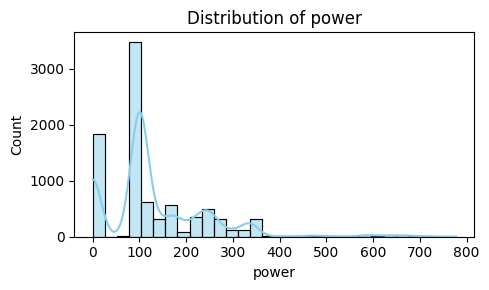

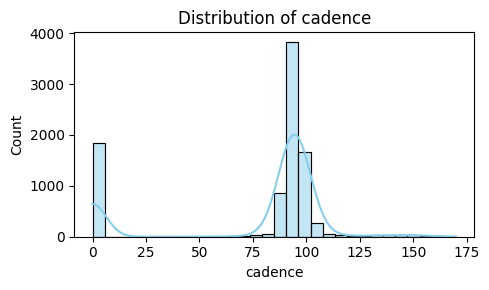

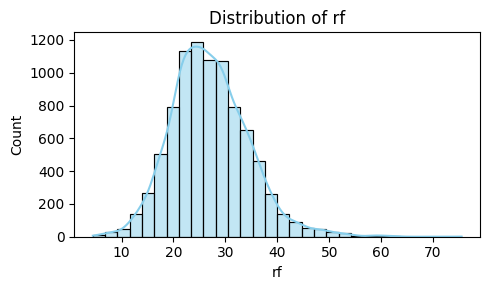

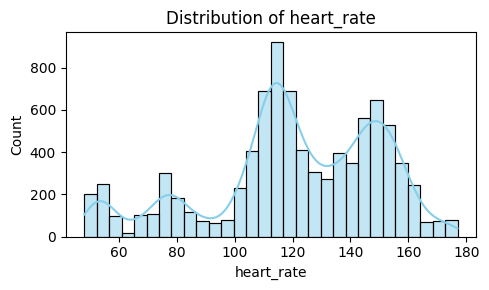

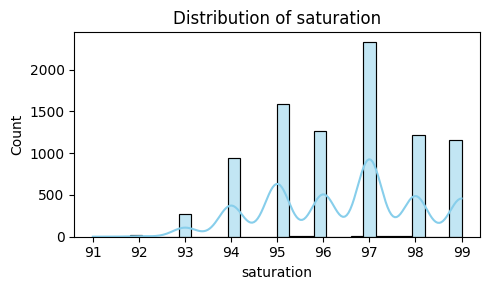

In [38]:
for col in X.columns:
    if col == "const":
        continue
    plt.figure(figsize=(5, 3))
    sns.histplot(X[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

**3. Linearity & Homoscedasticity — Residuals vs Fitted**

Our response is bounded. The bottom left "line" in the graph that runs from (0,2) to (4,-4) represents the lower bound, then the "line" that is in the most top-right part of the graph represents the outer bound.

Because our response is bounded, this residuals vs fitted makes sense.


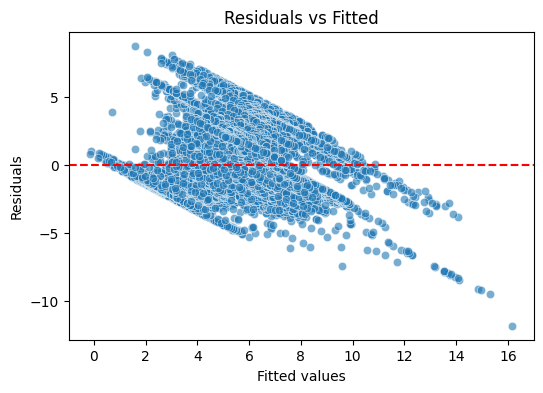

In [39]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

**4. Normality of Residuals — Q-Q Plot**

Generally the normality assumption is upheld with some slight deviation at the top left tail.

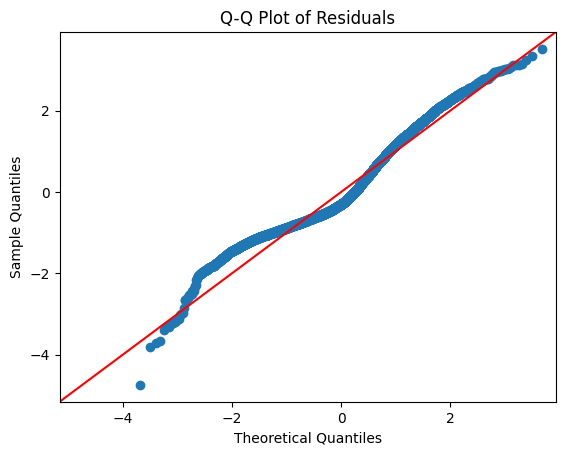

Shapiro-Wilk p-value: 2.2162708198701393e-48


/Users/evaharris/Desktop/Classes/CS109a/CS109A---Final-Project-Blood-Lactate-Analysis/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8818.
  res = hypotest_fun_out(*samples, **kwds)


In [40]:
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro–Wilk Test for Normaility as well -- p > 0.5 is usually good
stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)


**5. Independence — Residuals vs Time (or Duration)**

There is a trend in these residuals, however it can be explained by the bounded nature of our data. We can make it look prettier with a sigmoidal transformation, however, per office hours it is not necessary.

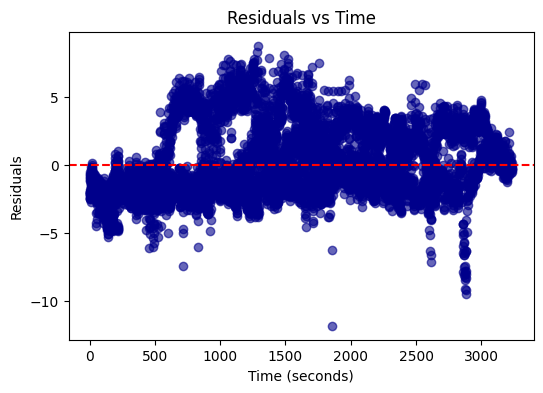

In [41]:
plt.figure(figsize=(6, 4))
plt.scatter(df["time"], residuals, alpha=0.6, color="darkblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Time (seconds)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


**6. Residual Histogram**

The histogram of residuals looks good!

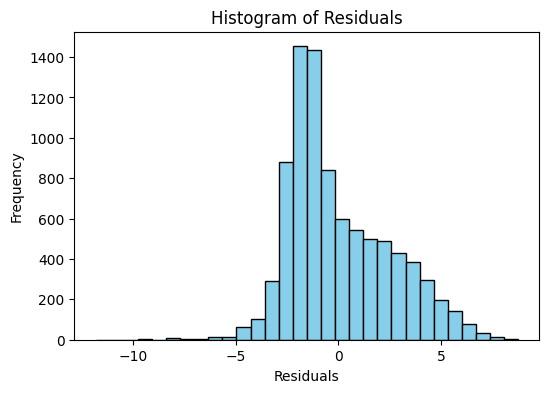

In [42]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()


## 5 - Prediction Models


In [43]:
# Add to imports in section 2.1 (if not already there)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, GridSearchCV, KFold

### 5.1 - Standard (OLS) Multiple Linear Regression

In [44]:
# Prepare features and target
X = df.drop(['lactate', 'time', 'day'], axis=1)  # Remove lactate (target) and time
y = df['lactate']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Baseline Linear Model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Cross-validation score
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(baseline_model, X, y, cv=tscv, scoring='r2')
y_pred_baseline = baseline_model.predict(X)

print(f"Training  R^2: {baseline_model.score(X_train, y_train):.4f}")
print(f"Test  R^2: {baseline_model.score(X_test, y_test):.4f}")
print(f"Cross-validation  R^2 (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Training  R^2: 0.3998
Test  R^2: 0.3997
Cross-validation  R^2 (5-fold): -4.3688 (+/- 14.9198)


### 5.2 - LASSO

In this section, we aim to evaluate more advanced predictions models ability to predict blood lactate. In an attempt to address collinearity in our features and decide which features are most important before deciding on our final model, we started by utilizing Ridge and LASSO regression. To establish a performance benchmark for these models, we ran a baseline linear model to establish a performance benchmark. The baseline uses a simple linear regression approach with our features of interest, without any regularization or feature engineering. This allows us to evaluate how well a straightforward linear relationship fits the data before shrinking coefficients.

In [45]:
# LASSO Regression 
alphas = np.logspace(-4, 1, 50)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42, n_jobs=-1)

# Fit the model
lasso_cv.fit(X_train, y_train)
y_pred_lasso = lasso_cv.predict(X)

print(f"Best alpha from cross-validation: {lasso_cv.alpha_:.6f}")
print(f"Training R^2: {lasso_cv.score(X_train, y_train):.4f}")
print(f"Test R^2: {lasso_cv.score(X_test, y_test):.4f}")
print(f"Number of features used: {np.sum(lasso_cv.coef_ != 0)}")

# Display feature importance
feature_importance_lasso = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lasso_cv.coef_,
    'abs_coefficient': np.abs(lasso_cv.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 5 most important features (LASSO):")
print(feature_importance_lasso.head(5).to_string(index=False))

Best alpha from cross-validation: 0.000100
Training R^2: 0.3998
Test R^2: 0.3997
Number of features used: 5

Top 5 most important features (LASSO):
   feature  coefficient  abs_coefficient
saturation       -0.535            0.535
        rf        0.237            0.237
   cadence       -0.018            0.018
heart_rate        0.004            0.004
     power       -0.002            0.002


LASSO regression introduces L1 regularization, which penalizes the absolute size of coefficients. This reduces collinearity by driving some coefficients to zero, effectively performing feature selection. We use LASSO to identify the most important predictors of blood lactate levels while reducing overfitting.


### 5.3 - RIDGE

Similar to LASSO, RIDGE regression applies L2 regularization, penalizing the squared magnitude of coefficients. This technique shrinks coefficients but does not eliminate them entirely, making it useful in case all features have influence on our target, blood lactate

In [46]:
# RIDGE Regression 
ridge_cv = RidgeCV(alphas=alphas, cv=5)

# Fit the model
ridge_cv.fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X)

print(f"Best alpha from cross-validation: {ridge_cv.alpha_:.6f}")
print(f"Training R^2: {ridge_cv.score(X_train, y_train):.4f}")
print(f"Test R^2: {ridge_cv.score(X_test, y_test):.4f}")

# Display feature importance for ridge
feature_importance_ridge = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ridge_cv.coef_,
    'abs_coefficient': np.abs(ridge_cv.coef_)
}).sort_values('abs_coefficient', ascending=False)

print("\nTop 5 most important features (RIDGE):")
print(feature_importance_ridge.head(5).to_string(index=False))


Best alpha from cross-validation: 0.000100
Training R^2: 0.3998
Test R^2: 0.3997

Top 5 most important features (RIDGE):
   feature  coefficient  abs_coefficient
saturation       -0.535            0.535
        rf        0.237            0.237
   cadence       -0.018            0.018
heart_rate        0.004            0.004
     power       -0.002            0.002


Both the Ridge and the LASSO models perform exactly the same as the baseline linear model with a Test R^2 of 0.3998. This shows none of the features were reduced by regularization. The top 3 features by importance across these models were saturation, rf, and cadence. 

### 5.4 - Polynomial

Polynomial regression serves as our first explicit non-linear modeling approach. This model is particularly relevant for our physiological data because It provides a bridge between simple linear models and more complex non-linear approaches, allowing us to test whether polynomial terms significantly improve predictions. The model remains interpretable through its polynomial coefficients, unlike "black box" approaches like decision trees.

In [47]:
# Polynomial Regression
# Try different polynomial degrees
degrees = [2, 3, 4, 5]
best_poly_score = -np.inf
best_poly_degree = 2
best_poly_model = None
y_pred_poly_best = None

poly_results = []

for degree in degrees:
    print(f"\nTesting polynomial degree {degree}:")
    
    # Create polynomial features pipeline
    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg', LinearRegression())
    ])
    
    # Fit the model
    poly_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred_poly = poly_model.predict(X)
    
    # Calculate scores
    train_score = poly_model.score(X_train, y_train)
    test_score = poly_model.score(X_test, y_test)
    
    print(f"  Training R^2: {train_score:.4f}")
    print(f"  Test R^2: {test_score:.4f}")
    
    # Cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores_poly = cross_val_score(poly_model, X, y, cv=tscv, scoring='r2')
    print(f"  Cross-validation R^2 (5-fold): {cv_scores_poly.mean():.4f} (+/- {cv_scores_poly.std() * 2:.4f})")
    
    poly_results.append({
        'degree': degree,
        'train_score': train_score,
        'test_score': test_score,
        'cv_score': cv_scores_poly.mean(),
        'n_features': poly_model.named_steps['poly'].n_output_features_
    })
    
    # Track best model
    if test_score > best_poly_score:
        best_poly_score = test_score
        best_poly_degree = degree
        best_poly_model = poly_model
        y_pred_poly_best = y_pred_poly

print(f"\nBest polynomial degree: {best_poly_degree} with test R^2: {best_poly_score:.4f}")
print(f"Number of polynomial features created: {best_poly_model.named_steps['poly'].n_output_features_}")


Testing polynomial degree 2:
  Training R^2: 0.5724
  Test R^2: 0.5872
  Cross-validation R^2 (5-fold): -4.2104 (+/- 14.0024)

Testing polynomial degree 3:
  Training R^2: 0.6741
  Test R^2: 0.6667
  Cross-validation R^2 (5-fold): -7.0891 (+/- 13.7372)

Testing polynomial degree 4:
  Training R^2: 0.7170
  Test R^2: 0.6980
  Cross-validation R^2 (5-fold): -56.1872 (+/- 99.8689)

Testing polynomial degree 5:
  Training R^2: 0.7475
  Test R^2: -0.6153
  Cross-validation R^2 (5-fold): -5548.7434 (+/- 15288.4442)

Best polynomial degree: 4 with test R^2: 0.6980
Number of polynomial features created: 125


The results of our polynomial model show severe overfitting to the training data, and degree 4 is the highest usable degree before complete model collapse. Degree 2 gives the most stable performance (test R²: 0.587, CV: -4.21) despite lower training R².

## 6 - Tree Models

In this section, we will fit and predict on the dataset utilizing tree models such as Decision Trees, Random Forests, Gradient Boosting, and Mixture of Experts (with trees). 

Why use tree models? Because linear and even polynomial models may struggle to capture less straightforward relationships in the data that a tree can. 

### 6.1 - Decision Tree

In the code below, we build a Decision Tree, fit it on the training set, cross-validate to tune hyperparameters, predict on the test set, and compute the R-squared value to evaluate the model. This model is called "best_dt".

In [48]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

dt_1 = DecisionTreeRegressor(random_state=42)

# tune hyperparameters

param_grid_dt = {
    "max_depth": [3, 5, 10, 20, 25, None],
    "min_samples_split": [2, 3, 5, 10],
    "min_samples_leaf": [1, 5, 10, 20],
    "ccp_alpha": [0.0, 0.01],
}

dt_grid = GridSearchCV(
    estimator=dt_1,
    param_grid=param_grid_dt,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# fit
dt_grid.fit(X_train, y_train)

# choose best_dt
best_dt = dt_grid.best_estimator_
print(dt_grid.best_params_)

# predict
y_train_pred_dt = best_dt.predict(X_train)
y_test_pred_dt  = best_dt.predict(X_test)

# score
train_dt_score = r2_score(y_train, y_train_pred_dt)
test_dt_score = r2_score(y_test, y_test_pred_dt)
print(f"best_dt Train R^2: {train_dt_score:.4f}")
print(f"best_dt Test  R^2: {test_dt_score:.4f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits
{'ccp_alpha': 0.0, 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}
best_dt Train R^2: 0.9605
best_dt Test  R^2: 0.8930


The Decision Tree results show:

Train R^2: 0.9605

Test  R^2: 0.8930

Best parameters: {'ccp_alpha': 0.0, 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 2}

This means it now has two stopping conditions: (1) the tree cannot grow past a depth of 20; and (2) every leaf must have at least 5 samples. Also, the best_dt model is not pruned because ccp_alpha = 0.0.

Overall, the test R^2 improved compared to the linear and polynomial models. However, the model is overfitting.

Next, I will check which features are the most important by building a function called display_feature_importances.

In [49]:
def display_feature_importances(importances):
    sorted_idx = np.argsort(importances)[::-1]
    top_features = np.array(X_train.columns)[sorted_idx]
    top_importances = importances[sorted_idx]
    feature_table = pd.DataFrame({
        "feature": top_features,
        "importance": top_importances
    })
    display(feature_table)

In [50]:
display_feature_importances(best_dt.feature_importances_)

,feature,importance
0,saturation,0.272
1,power,0.258
2,rf,0.230
3,heart_rate,0.196
4,cadence,0.043


This shows that saturation, power, and rf in that order predict lactate the best according to the decision tree model. At the end of this section, I will interpret these results further once I've checked the feature importances for all the other models to see if there is a common pattern. Note that the feature cadence does not significantly affect this model.

### 6.2 - Random Forest

To address the overfitting problem, we will next try the Random Forest model. Because of the bagging inherent in the Random Forest model, each tree fits on a different subset of features, which helps mitigate overfitting. In the code below, I will again use cross-validation to tune hyperparameters for a Random Forest model called "best_rf". I chose the hyperparameter options for the RF model based on the best hyperparameters chosen in the previous best_dt model.

In [51]:
rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)

# tune hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

rf_grid = GridSearchCV(
    rf_model, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

# fit
rf_grid.fit(X_train, y_train)

# best model
best_rf = rf_grid.best_estimator_
print(rf_grid.best_params_)

# predict
y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf  = best_rf.predict(X_test)

# score
train_rf_score = r2_score(y_train, y_train_pred_rf)
test_rf_score = r2_score(y_test, y_test_pred_rf)
print(f"best_rf Train R^2: {train_rf_score:.4f}")
print(f"best_rf Test  R^2: {test_rf_score:.4f}")

# get feature importances
display_feature_importances(best_rf.feature_importances_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
best_rf Train R^2: 0.9913
best_rf Test  R^2: 0.9386


,feature,importance
0,saturation,0.265
1,rf,0.244
2,power,0.242
3,heart_rate,0.193
4,cadence,0.057


The results are as follows:

best_rf Train R^2: 0.9913

best_rf Test  R^2: 0.9386

This suggests that there is still an issue with overfitting, but the noticeably higher test R-squared of 0.939 is an improvement over the previous Decision Tree model, which had a test R-squared of 0.893.

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Notably, the chosen optimized hyperparameters do not impose stopping conditions on this model, unlike the Decision Tree model.

Next, the results of feature importances reveal that the most important features in the Random Forest model mimic those of the Decision Tree model: saturation, rf, power.

### 6.3 - Gradient Boosting

Next, we try Gradient Boosting because it generally outperforms Random Forest. This outperformance stems from Gradient Boosting's iterative learning from its mistakes through training on residuals. Gradient Boosting should also help with overfitting, since it uses small trees. 

Our new Gradient Boosting model will be called "gbr".

In [52]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42,
    subsample=0.8,
)

param_grid_gbr = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3], # keep it small
    "subsample": [0.6, 0.8, 1.0],
    "min_samples_leaf": [5, 10, 20]
}

gbr_grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    scoring="r2",
    cv=3,      
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

# fit
gbr_grid.fit(X_train, y_train)

# best model
best_gbr = gbr_grid.best_estimator_
print(gbr_grid.best_params_)

# predictions
y_train_pred_gbr = best_gbr.predict(X_train)
y_test_pred_gbr = best_gbr.predict(X_test)

# score
train_gbr_score = r2_score(y_train, y_train_pred_gbr)
test_gbr_score = r2_score(y_test, y_test_pred_gbr)
print(f"best_gbr Train R^2: {train_gbr_score:.4f}")
print(f"best_gbr Test  R^2: {test_gbr_score:.4f}")

# get feature importances
display_feature_importances(best_gbr.feature_importances_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 800, 'subsample': 0.8}
best_gbr Train R^2: 0.9447
best_gbr Test  R^2: 0.9102


,feature,importance
0,power,0.268
1,rf,0.247
2,saturation,0.231
3,heart_rate,0.198
4,cadence,0.055


The results are:

best_gbr Train R^2: 0.9447

best_gbr Test  R^2: 0.9102

Surprisingly, GradientBoosting yields a worse R-squared than the Random Forest model: 0.910 compared to 0.939. 

Why does this happen even though Gradient Boosting generally outperforms Random Forest?

We believe that gradient boosting doesn’t do quite as well as the Random Forest here because of how the two methods learn. A Random Forest builds many deep, independent trees and averages them, helping it capture complex patterns in the data without overfitting. Gradient boosting, on the other hand, builds many small trees one after another, each only fixing the errors of the previous tree. This makes gradient boosting more sensitive: it can miss complex relationships unless tuned very carefully, and when the data are noisy or have sudden jumps (as physiological signals often do, as shown by the EDA earlier), boosting can struggle.

The feature importances primarily line up with those of Random Forest.

### 6.4 - Mixture of Experts

I still want to fix the overfitting problem. But maybe we can instead overfit locally, so that, overall, averaging across clusters works out. We do this through a Mixture of Experts model, where each expert is a Random Forest model since that was our best-performing model so far. Furthermore, we know from the EDA that the data exhibit different patterns by day, so a Mixture of Experts model could differentiate between days and create clusters accordingly.

Ultimately, this model was unbelievably difficult to code. There wasn't an existing package to import.

As shown below, we define a new class called "RFMixtureOfExperts" that fits different RF models to different clusters of the dataset, and use KMeans to learn a gating function that distinguishes between the clusters.

In [53]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.cluster import KMeans
from sklearn.utils.validation import check_is_fitted

class RFMixtureOfExperts(BaseEstimator, RegressorMixin):

    # inherit from BaseEstimator to tune hyperparameters later using GridSearchCV
    # inherit from RegressorMixin b/c it adds a score method

    # init default values
    def __init__(
        self,
        n_experts=3,
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
    ):

    # but also set these features; basically all from random_forest besides the "n_experts"
        self.n_experts = n_experts
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    ################
    # FIT FUNCTION #
    ################
    
    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        # this is the gating function
        self.kmeans_ = KMeans(
            n_clusters=self.n_experts,
            random_state=self.random_state,
            n_init="auto"
        )
        cluster_labels = self.kmeans_.fit_predict(X)

        # for each cluster defined, we train an expert
        self.experts_ = []
        for k in range(self.n_experts):
            idx = np.where(cluster_labels == k)[0]
            X_k, y_k = X[idx], y[idx]   # <— define cluster data
        
            rf = RandomForestRegressor(
                n_estimators=self.n_estimators,
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                random_state=self.random_state + k,
                n_jobs=-1
            )
            rf.fit(X_k, y_k)
            self.experts_.append(rf)

        return self

    ####################
    # PREDICT FUNCTION #
    ####################
    
    def predict(self, X):
        check_is_fitted(self, ["kmeans_", "experts_"])
        X = np.asarray(X)

        # figure out what cluster a particular sample is in
        cluster_pred = self.kmeans_.predict(X)

        # now predict it
        y_pred = np.zeros(X.shape[0], dtype=float)
        for k, expert in enumerate(self.experts_):
            idx = np.where(cluster_pred == k)[0]
            if len(idx) > 0:
                y_pred[idx] = expert.predict(X[idx])

        return y_pred

Now, we will create an instance of this class and tune the hyperparameters using the GridSearchCV methods we've done before, and then we choose the best model which we name "best_moe", and calculate the R-squared of this optimized Mixture of Experts model.

In [54]:
moe_rf = RFMixtureOfExperts(random_state=42)

# copied from my RF param grid earlier
param_grid_moe = {
    "n_experts": [2, 3, 4],
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5],
}

# hyperparameter tuning
moe_grid = GridSearchCV(
    estimator=moe_rf,
    param_grid=param_grid_moe,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
moe_grid.fit(X_train, y_train)
best_moe = moe_grid.best_estimator_
print("Best MoE RF params:", moe_grid.best_params_)

train_moe_score = r2_score(y_train, best_moe.predict(X_train))
test_moe_score  = r2_score(y_test, best_moe.predict(X_test))

print(f"best_moe Train R^2: {train_moe_score:.4f}")
print(f"best_moe Test R^2: {test_moe_score:.4f}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/Users/evaharris/Desktop/Classes/CS109a/CS109A---Final-Project-Blood-Lactate-Analysis/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/evaharris/Desktop/Classes/CS109a/CS109A---Final-Project-Blood-Lactate-Analysis/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/evaharris/Desktop/Classes/CS109a/CS109A---Final-Project-Blood-Lactate-Analysis/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Pa

Best MoE RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'n_experts': 3}
best_moe Train R^2: 0.9914
best_moe Test R^2: 0.9392


The results are:

Best MoE RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'n_experts': 3}

best_moe Train R^2: 0.9914

best_moe Test R^2: 0.9392

This ends up being practically the same as RandomForest! This suggests that fitting different RF models to different clusters has little effect. In other words, the clusters are not meaningful. I want to investigate the clusters further to see why this may be the case. I do this by defining two functions: a summarize_gating function that computes the average feature values per cluster, and an expert_counts function that counts the number of training set datapoints assigned to each cluster by the gating function of the Mixture of Experts model.

In [55]:
def summarize_gating(model, X, feature_names):
    X = np.asarray(X)
    centers = model.kmeans_.cluster_centers_
    centers_df = pd.DataFrame(centers, columns=feature_names)
    centers_df.index = [f"Expert {k}" for k in range(model.n_experts)]
    return centers_df

def expert_counts(model, X):
    X = np.asarray(X)
    cluster_labels = model.kmeans_.predict(X)
    counts = pd.Series(cluster_labels).value_counts().sort_index()
    counts.index = [f"Expert {k}" for k in counts.index]
    return counts

print("Relevant Features")
print(summarize_gating(best_moe, X_train, X_train.columns))

print("\nNumber of Samples in Each Cluster")
print(expert_counts(best_moe, X_train))

Relevant Features
            power  cadence      rf  heart_rate  saturation
Expert 0  153.329   94.679  28.695     130.564      96.581
Expert 1    0.253    0.046  20.486      82.701      95.916
Expert 2  578.233  137.113  32.556     136.349      96.333

Number of Samples in Each Cluster
Expert 0    5447
Expert 1    1448
Expert 2     159
Name: count, dtype: int64


Ultimately, these results suggest that the clusters are not particularly meaningful, as power appears to be the main differentiating factor among the clusters. In other words, it does not identify patterns that are too different from how the Random Forest model can already split. 

### 6.5 - Model Comparisons

Now that we've fit and run all our models, let's compare the R-squared between all!

In [56]:
# data

comparison_data = {
    'Model': [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Mixture of Experts",
    ],
    'Train R^2': [
        train_dt_score,
        train_rf_score,
        train_gbr_score,
        train_moe_score
    ],
    'Test R^2': [
        test_dt_score,
        test_rf_score,
        test_gbr_score,
        test_moe_score
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Model,Train R^2,Test R^2
0,Decision Tree,0.961,0.893
1,Random Forest,0.991,0.939
2,Gradient Boosting,0.945,0.910
3,Mixture of Experts,0.991,0.939


## 7 - Extension: A Feature Exploration Of Oxygen Saturation (via Bayesian Hierarchal Model)

The `Random Forest` model in `Section 5.5` was one of our best performing models. This model marked `saturation` as our most important feature (with a value of 0.265). To further explore this variable, we fit a Bayesian hierarchical linear model predicting lactate as a function of oxygen saturation. Because it looks like the athlete did different pieces at heart rate (e.g. three long pieces in the first day but bursts on the third day), we took both intercepts and slopes varying by day. This structure is helpful it allows each training day to have its own baseline lactate level and its own sensitivity of lactate to saturation. 

It still shares information across days through group-level priors. The results indicate meaningful differences in baseline lactate levels between each day's observations. Additionally, there are consistently negative saturation x lactate relationships across all days. The hierarchical formulation appears to improve stability and interpretability relative to fitting separate models per day by borrowing strength across groups. Ideally this will also explicitly account for the variability in the athlete's testing intervals between days in the regression coefficients.

In [57]:
import numpy as np
import arviz as az
import pymc as pm

np.random.seed(42)

# number of groups 
n_days = df["day"].nunique() 
# day index per row: {0,1,2} 
day_idx = df["day"].values.astype(int) - 1 

sat = df["saturation"].values 
lactate = df["lactate"].values 

with pm.Model() as hierarchical_model: 
    # Hyperpriors for intercepts 
    mu_a = pm.Normal('b0_mu', mu=0., sigma=100.) 
    sigma_a = pm.HalfNormal('b0_sigma', 5.) 
    
    # Hyperpriors for slopes 
    mu_b = pm.Normal('b1_mu', mu=0., sigma=100.) 
    sigma_b = pm.HalfNormal('b1_sigma', 5.) 
    
    # Day-specific intercepts and slopes 
    a = pm.Normal('b0', mu=mu_a, sigma=sigma_a, shape=n_days) # (3,) 
    b = pm.Normal('b1', mu=mu_b, sigma=sigma_b, shape=n_days) # (3,) 
    
    # Linear predictor for each observation 
    y_mu = a[day_idx] + b[day_idx] * sat 
    
    # Observation noise 
    sigma = pm.HalfNormal('sigma', 5.) 
    
    # Likelihood 
    y = pm.Normal('y', mu=y_mu, sigma=sigma, observed=lactate) 

with hierarchical_model:
    trace = pm.sample(
        draws=500,
        tune=500,
        target_accept=0.9,
        cores=1,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [b0_mu, b0_sigma, b1_mu, b1_sigma, b0, b1, sigma]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 447 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b0_mu,126.799,6.769,115.459,141.358,0.214,0.253,1025.0,573.0,1.00
b1_mu,-1.281,0.380,-1.923,-0.645,0.028,0.063,571.0,155.0,1.00
b0[0],127.163,2.715,122.079,132.186,0.156,0.106,303.0,419.0,1.01
b0[1],110.580,2.700,105.783,115.763,0.159,0.090,288.0,429.0,1.00
b0[2],145.211,2.794,140.516,150.826,0.140,0.096,398.0,386.0,1.01
b1[0],-1.264,0.028,-1.316,-1.211,0.002,0.001,302.0,419.0,1.01
b1[1],-1.113,0.028,-1.167,-1.062,0.002,0.001,288.0,429.0,1.00
b1[2],-1.418,0.029,-1.476,-1.370,0.001,0.001,398.0,386.0,1.01
b0_sigma,10.838,2.528,6.429,15.652,0.085,0.090,911.0,575.0,1.00
b1_sigma,0.523,0.767,0.063,1.438,0.056,0.123,286.0,226.0,1.00


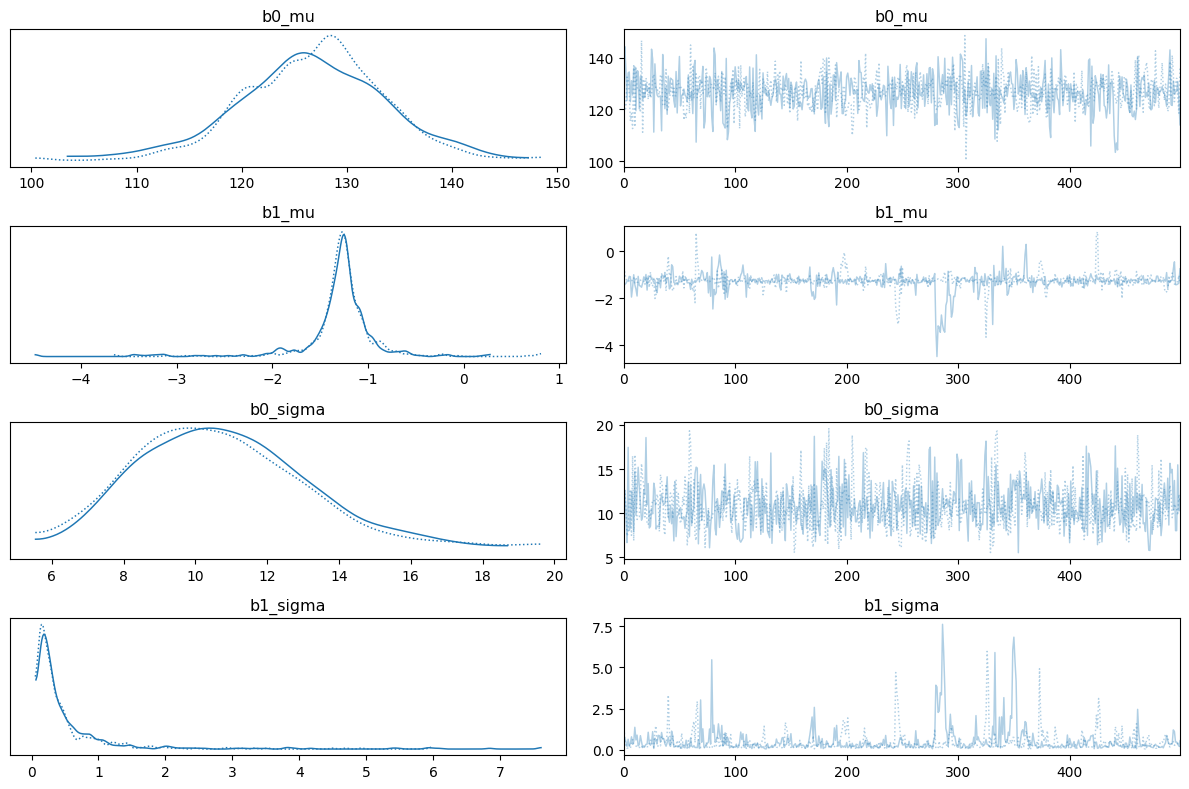

In [58]:
pm.plot_trace(trace, var_names=['b0_mu', 'b1_mu',
                                            'b0_sigma', 'b1_sigma'])
plt.tight_layout();

results = pm.summary(trace)
results[:10]

Now we will sample from our hierarchical model to get the posterior. In the below code, we found that the bayesian posterior predictive $R^2$ was 0.5144. While our main intent for implementing bayesian hierarical modeling was to better understand our most important feature `saturation`, I decided to do a brief extension and compare the fitted hierarical model (with 1 predictor) with the rest of our models fitted thus far. Comparing this against the other $R^2$ models from the test set, we get the following:


**Model Performance Comparison (Test $R^2$)**

| Model                         | Test $R^2$|
|-------------------------------|-----------|
| Baseline Linear               | 0.400     |
| LASSO (CV)                    | 0.400     |
| RIDGE (CV)                    | 0.400     |
| Bayesian Hierarchical (Sat)   | 0.514     |
| Polynomial Regression (deg=4) | 0.698     |
| Random Forest                 | 0.939     |
| Gradient Boosting             | 0.910     |
| Mixture of Experts            | 0.939     |


In [59]:
with hierarchical_model:
    ppc = pm.sample_posterior_predictive(trace)

# Extract y predictions
y_ppc = ppc.posterior_predictive["y"].values

# Collapse chains + draws to get posterior predictive samples
y_ppc = y_ppc.reshape(-1, y_ppc.shape[-1])

# Posterior predictive mean
y_hat = y_ppc.mean(axis=0)

# Compute R^2
y_true = lactate

ss_res = np.sum((y_true - y_hat) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Bayesian posterior predictive R^2: {r2:.4f}")


Sampling: [y]


Output()

Bayesian posterior predictive R^2: 0.5139


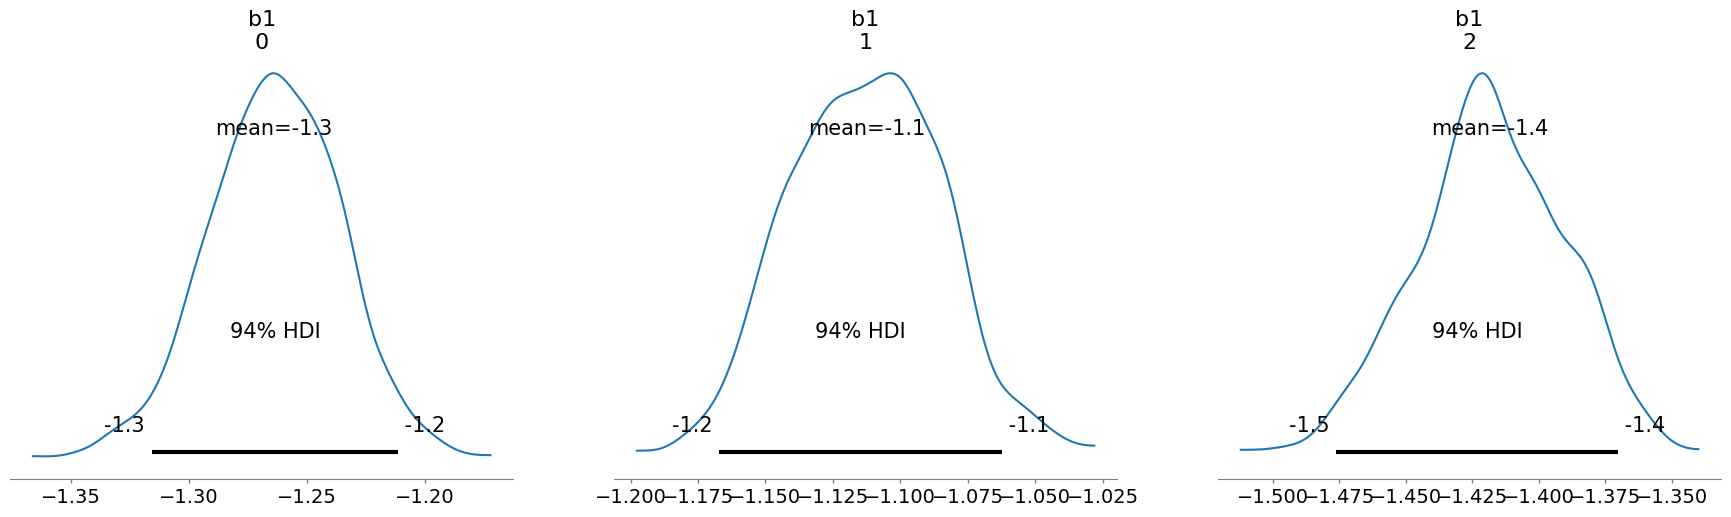

In [60]:
pm.plot_posterior(trace, var_names=['b1']);

**Interpretation of the three posterior slope plots: Day 1 is $b1[0]$, Day 2 is $b1[1]$ and Day 3 is $b1[2]$**

All three plots show strongly negative values with narrow 94% HDIs that do not overlap zero. This confirms an inverse relationship between oxygen saturation and lactate on every training day. 

Considering the slope of each graph, Day 1’s slope centers around roughly –1.3, Day 2’s around –1.1, and Day 3’s around –1.4.

This indicates that decreases in saturation are consistently associated with meaningful increases in lactate, but with slightly different magnitudes depending on the workout structure for each day. 

The differences in slope steepness across days are physiologically plausible given the distinct interval patterns performed. For instance, Day 3’s most intense burst-style efforts correspond to the steepest lactate response (–1.4), while Day 2’s more stable effort pattern yields the mildest slope (–1.1). 

The hierarchical model captures these differences while still borrowing strength across days, and the tight posterior intervals indicate high certainty in the direction and magnitude of the saturation–lactate relationship.

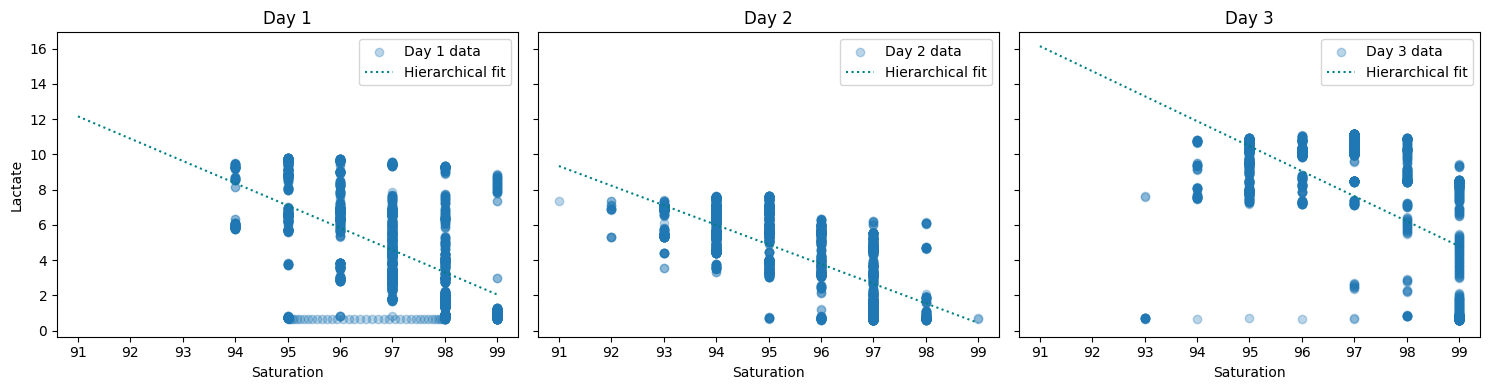

In [61]:
import numpy as np
import matplotlib.pyplot as plt

days = np.sort(df["day"].unique())
n_days = len(days)

# grid of saturation values for drawing the fitted lines
sat_min, sat_max = df["saturation"].min(), df["saturation"].max()
xx = np.linspace(sat_min, sat_max, 100)

# posterior means (of day-specific intercepts and slopes)
b0_mean = trace.posterior["b0"].mean(dim=("chain", "draw")).values  # shape (n_days,)
b1_mean = trace.posterior["b1"].mean(dim=("chain", "draw")).values  # shape (n_days,)

fig, axs = plt.subplots(1, n_days, figsize=(5 * n_days, 4), sharey=True)

for i, day in enumerate(days):
    ax = axs[i]

    # data for this day
    mask = df["day"] == day
    sat_day = df.loc[mask, "saturation"]
    lact_day = df.loc[mask, "lactate"]

    # scatter of observed data
    ax.scatter(sat_day, lact_day, alpha=0.3, label=f"Day {day} data")

    # hierarchical fitted line for this day
    y_hat_hier = b0_mean[i] + b1_mean[i] * xx
    ax.plot(xx, y_hat_hier, c="teal", ls=":", label="Hierarchical fit")

    ax.set_xlabel("Saturation")
    if i == 0:
        ax.set_ylabel("Lactate")
    ax.set_title(f"Day {day}")
    ax.legend()

plt.tight_layout()
plt.show()


Overall, these fits look really solid. They show lactate versus oxygen saturation for each training day, with the dotted line representing the fitted relationship from the Bayesian hierarchical model. Across all three days, the fitted lines slope downward, visually confirming the model result that lower oxygen saturation is associated with higher lactate levels. 

It's interesting that you can see visually that the slope and intercept differ by day. The structural differences of the intervals  between days has been something we were mindful of throughout this notebook. I will now examine each of the above graphs individually:

- Day 1 shows a moderate negative trend with greater scatter at high saturation, consistent with longer steady efforts where lactate accumulates gradually. 

- Day 2 displays a slightly flatter slope and tighter clustering, suggesting more controlled or sustained efforts with less extreme lactate responses. 

- Day 3 shows the steepest decline, indicating that small drops in saturation correspond to sharp increases in lactate—consistent with high-intensity interval bursts. 

Overall, these panels demonstrate that the hierarchical model successfully captured both the shared physiological relationship between saturation and lactate and the day-specific adaptations driven by different training intervals. This was our goal of the extension, and I feel that we came out of this analysis with a better understanding of the behavior of our most important predictor, saturation.

## 8 - Conclusion

Our problem statement question asked whether a linear or non-linear framework would best predicts blood lactate levels from non-invasive physiological data.

The models with the best $R^2$ performance were Random Forest, Gradient Boosting, and and Mixture of Experts. These are all **nonlinear ensemble learning methods** that combine multiple models to capture complex, non-additive relationships in the data.